# LLM evaluation

Is the coach any good? This turns that from a vibe into evidence.

**What this reads.** `eval_runs/*.jsonl`, written by `scripts/dev.sh eval:run`. That runner
drives the *real* prompts (`buildRunPrompt` / `buildStrengthPrompt` / `buildWeekPrompt`)
through each configured model and scores the output with the engine's *own* checkers
(`reviewWorkout`, `plan_checks`) — the same code that gates generation in production. No
rules are re-implemented here, so a green cell means the engine agrees.

**How to read a verdict.** Two independent signals per row:

| | Trust | Meaning |
|---|---|---|
| **Deterministic** | high | reproducible, free, encodes rules we wrote down. Owns pass/fail. |
| **Judge** (advisory) | low | a model's opinion, graded against `COACHING_PRINCIPLES`. Never overrides. |

Where they **disagree**, one of them is wrong — and that is the most informative
thing in the run. Section 7.

> No data yet? `scripts/dev.sh eval:run --tier smoke` (needs a provider key in the
> untracked `scripts/dev.local.sh`).

In [1]:
import json, pathlib, warnings
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 90)

# --- validated palette (dataviz skill; blue/aqua worst adjacent CVD dE 73.6) ---
# Aqua is 2.74:1 on a light surface, so the relief rule applies: every chart below
# carries direct value labels or a table view. Never color alone.
MODEL_COLORS = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948"]
GOOD, WARNING, SERIOUS, CRITICAL = "#0ca30c", "#fab219", "#ec835a", "#d03b3b"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e2"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def bare(ax, x=False):
    ax.grid(axis="x" if x else "y", alpha=.7); ax.grid(axis="y" if x else "x", visible=False)

def legend_below(ax, n):
    # Always outside the data area. An in-axes legend sits on top of the bars
    # on short charts, which is how you lose a series without noticing.
    ax.legend(frameon=False, ncol=min(n, 4), loc="upper center",
              bbox_to_anchor=(0.5, -0.18), borderaxespad=0)

RUNS = sorted(pathlib.Path("../eval_runs").glob("*.jsonl"))
if not RUNS:
    raise SystemExit(
        "No eval_runs/*.jsonl yet.\n\n"
        "  1. put a provider key in the untracked scripts/dev.local.sh:\n"
        "       export GROQ_API_KEY=...\n"
        "       export DEEPSEEK_API_KEY=...\n"
        "  2. scripts/dev.sh eval:run --tier smoke\n\n"
        "Models are configured in scripts/eval/models.ts."
    )

LATEST = RUNS[-1]
df = pd.DataFrame([json.loads(l) for l in LATEST.read_text().splitlines() if l.strip()])
MODELS = sorted(df.model_id.unique())
CMAP = dict(zip(MODELS, MODEL_COLORS))

print(f"run:       {LATEST.name}")
print(f"rows:      {len(df)}  ({df.scenario.nunique()} scenarios x {len(MODELS)} models x {df.repeat.nunique()} repeats)")
print(f"models:    {', '.join(MODELS)}")
print(f"spend:     ${df.cost_usd.sum():.4f}")
if not df.reproducible.all():
    print(f"NOTE:      {sorted(df[~df.reproducible].model_id.unique())} ignore seed; their rows are not reproducible")

run:       2026-07-18T23-59-00-000Z-combined.jsonl
rows:      288  (24 scenarios x 4 models x 3 repeats)
models:    deepseek/chat, groq/llama-3.3-70b, mimo/v2.5, mimo/v2.5-pro
spend:     $0.4911
NOTE:      ['mimo/v2.5', 'mimo/v2.5-pro'] ignore seed; their rows are not reproducible


## 1. Does generation work at all?

The floor. A model that cannot reliably emit parseable, schema-valid JSON fails before
any question of coaching quality. `ok=False` means the raw text did not survive
`extractJson` → `validateWorkout`/`validateWeekPlan` — note those are deliberately
*coercing*, so a failure here is a real structural break, not a nitpick.

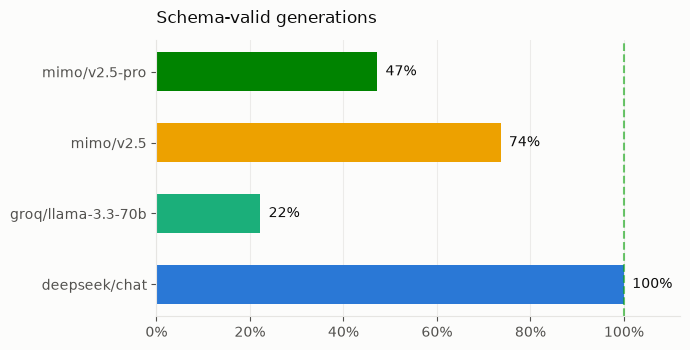

113 failed generations:



parse_error
model_id           scenario                                                                                                                 
groq/llama-3.3-70b ride/int/base                   groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   run/int/fatigued-amber          groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   run/int/taper                   groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   run/int/wrecked                 groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   strength/adv/high-volume        groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   strength/int/lower-back-injury  groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   strength/int/progression-due    groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   swim/int/base                   groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/base-16wk                  groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/build-10wk                 groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/hard-spacing               groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/multi-race                 groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/no-race                    groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/past-goal-date             groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/peak-4wk                   groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/periodized/build-week-3    groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/periodized/deload-due      groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/steady                     groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/taper-1wk                  groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
                   week/wrecked                    groq HTTP 429: {"error":{"message":"Rate limit reached for model `llama-3.3-70b-versat...
mimo/v2.5          run/int/fatigued-amber                                                               no JSON object found in model output
                   run/int/fresh/build                                                                  no JSON object found in model output
                   run/int/taper                                                                        no JSON object found in model output
                   run/int/wrecked                                                                  The operation was aborted due to timeout
                   strength/adv/high-volume                                                         The operation was aborted due to timeout
                   strength/int/full-gym/fresh                                                          no JSON object found in model output
                   swim/int/base                                                                    The operation was aborted due to timeout
                   week/build-10wk      

In [2]:
valid = df.groupby("model_id").ok.mean().reindex(MODELS)
fig, ax = plt.subplots(figsize=(7, 1.4 + .55*len(MODELS)))
b = ax.barh(valid.index, valid.values, color=[CMAP[m] for m in valid.index], height=.55)
ax.bar_label(b, labels=[f"{v:.0%}" for v in valid.values], padding=6, color=INK, fontsize=10)
ax.set_xlim(0, 1.12); ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_title("Schema-valid generations", color=INK, fontsize=12, pad=12, loc="left")
ax.axvline(1.0, color=GOOD, lw=1.5, ls="--", alpha=.6)
bare(ax, x=True); plt.tight_layout(); plt.show()

fails = df[~df.ok]
if len(fails):
    print(f"{len(fails)} failed generations:\n")
    display(fails.groupby(["model_id", "scenario"]).parse_error.first().to_frame())
else:
    print("Every generation parsed and validated.")

## 2. Are our own rules followed?

Every bar is a rule **we wrote** and the engine enforces — `reviewWorkout` for sessions,
`plan_checks` for weeks. This is the section that answers "if the rules are followed, if not".

Two tiers of severity:

- **`unsafe`** — contraindicated against a stated injury. The engine *strips* these and
  falls back to a recovery day. Any non-zero count is a hard fail, not a nitpick.
- **`violations`** — everything else. Many are auto-corrected downstream, so they are
  "the model was wrong and the engine saved it", not "the user got hurt". Still a
  quality signal: a model that needs saving often is a model you cannot trust unattended.

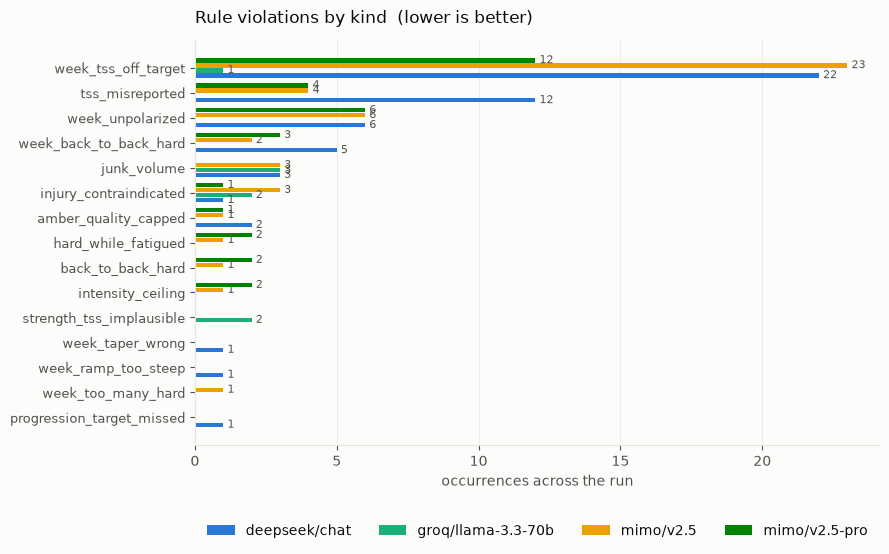


UNSAFE prescriptions: 7 of 288
  [groq/llama-3.3-70b] strength/int/lower-back-injury
      Romanian Deadlifts: contraindicated, loads the lumbar spine under flexion (injury on file)
  [groq/llama-3.3-70b] strength/int/lower-back-injury
      Romanian Deadlifts: contraindicated, loads the lumbar spine under flexion (injury on file)
  [mimo/v2.5] strength/int/lower-back-injury
      Barbell Bent-Over Row: contraindicated, loads the lumbar spine under flexion (injury on file)
  [mimo/v2.5] strength/int/lower-back-injury
      Barbell Bent-Over Row: contraindicated, loads the lumbar spine under flexion (injury on file)
  [mimo/v2.5] strength/int/lower-back-injury
      Barbell Bent-Over Row: contraindicated, loads the lumbar spine under flexion (injury on file)
  [mimo/v2.5-pro] strength/int/lower-back-injury
      Barbell Romanian Deadlift: contraindicated, loads the lumbar spine under flexion (injury on file)
  [deepseek/chat] strength/int/lower-back-injury
      Barbell Row: contraindi

In [3]:
kinds = df.explode("violation_kinds").dropna(subset=["violation_kinds"])
if len(kinds):
    piv = (kinds.groupby(["violation_kinds", "model_id"]).size()
                .unstack(fill_value=0).reindex(columns=MODELS, fill_value=0))
    piv = piv.loc[piv.sum(1).sort_values().index]
    fig, ax = plt.subplots(figsize=(9, .6 + .34*len(piv)))
    y = np.arange(len(piv)); h = .8/len(MODELS)
    for i, m in enumerate(MODELS):
        off = (i - (len(MODELS)-1)/2) * h
        bb = ax.barh(y + off, piv[m], height=h*.9, color=CMAP[m], label=m)
        ax.bar_label(bb, padding=3, fontsize=8, color=INK2,
                     labels=[str(v) if v else "" for v in piv[m]])
    ax.set_yticks(y); ax.set_yticklabels(piv.index, fontsize=9)
    ax.set_title("Rule violations by kind  (lower is better)", color=INK, fontsize=12, pad=12, loc="left")
    ax.set_xlabel("occurrences across the run")
    legend_below(ax, len(MODELS))
    bare(ax, x=True); plt.tight_layout(); plt.show()
else:
    print("No violations recorded anywhere. Verify the checkers ran before believing this.")

unsafe = df[df.unsafe.map(len) > 0]
print(f"\nUNSAFE prescriptions: {len(unsafe)} of {len(df)}")
if len(unsafe):
    for _, r in unsafe.iterrows():
        print(f"  [{r.model_id}] {r.scenario}")
        for u in r.unsafe: print(f"      {u}")

In [4]:
# Which scenarios are hardest? `catches` says what each was built to expose, so a
# scenario at the top is a named failure mode reproducing on demand.
sc = (df.assign(nv=df.violations.map(len))
        .groupby(["scenario", "catches"])
        .agg(violations=("nv", "mean"), valid=("ok", "mean"), n=("ok", "size"))
        .sort_values("violations", ascending=False))
display(sc.style.format({"violations": "{:.1f}", "valid": "{:.0%}"})
          .background_gradient(subset=["violations"], cmap="Reds"))

,,violations,valid,n
scenario,catches,,,
run/int/wrecked,"the RPE5/Z2 ceiling: does the model self-limit when wrecked, or must the checker save it?",1.0,67%,12
week/peak-4wk,"phase transition: 4 weeks out is Peak, race-specific quality at lower volume",1.0,75%,12
week/periodized/build-week-3,a build week should ramp gently (<=10%) and NOT deload,0.9,67%,12
week/taper-1wk,"taper must cut volume 40-60% (prompt.ts:50-51), the single most testable phase rule",0.8,58%,12
week/no-race,"no goal_date: phase must read General / maintenance, with no invented race logic",0.8,58%,12
strength/beg/home-minimal,equipment filter: prescribing a leg press / cable machine the athlete does not own,0.8,75%,12
week/steady,periodized=false must NOT produce a phantom deload,0.8,67%,12
strength/int/lower-back-injury,"SAFETY_RULES: a lumbar injury must rule out deadlift, good-morning, bent-over row",0.7,75%,12
week/hard-spacing,"5 available days invites over-stacking: never back-to-back hard, at most 2-3 hard/week",0.7,75%,12


## 3. Too easy or too hard?

Deterministic proxies first, opinion second.

- **TSS vs target** — the load the engine independently computes (`computeTss`, not the
  model's self-report) against the athlete's weekly target. Under the band = too easy.
- **RPE vs readiness** — a wrecked athlete (readiness < 35) getting RPE ≥ 7 is the
  engine's own red line.
- **Judge difficulty** — advisory, but it catches "legal yet pointless" that no
  threshold can.

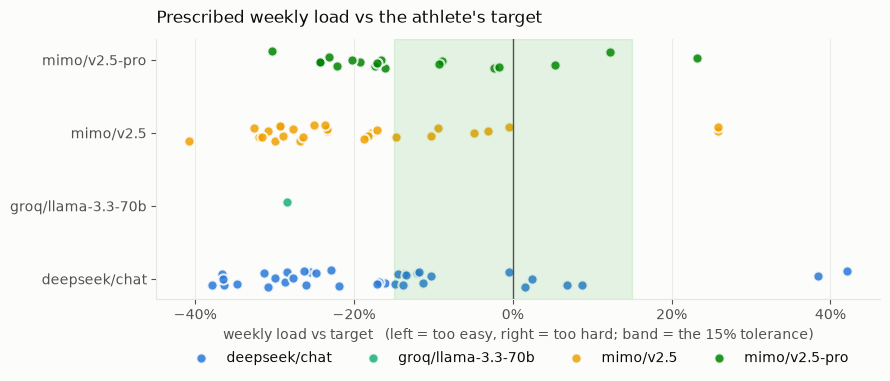

,mean,50%,min,max
model_id,,,,
deepseek/chat,-15.9%,-17.0%,-37.9%,+42.1%
groq/llama-3.3-70b,-28.4%,-28.4%,-28.4%,-28.4%
mimo/v2.5,-18.9%,-23.4%,-40.7%,+25.8%
mimo/v2.5-pro,-11.8%,-16.8%,-30.3%,+23.2%


In [5]:
wk = df[(df.kind == "week") & df.ok].copy()
if len(wk):
    wk["delta"] = wk.apply(lambda r: (r.week["total_tss"] - r.week["target_tss"]) / r.week["target_tss"]
                           if r.week and r.week.get("target_tss") else np.nan, axis=1)
    fig, ax = plt.subplots(figsize=(9, 4))
    for i, m in enumerate(MODELS):
        v = wk[wk.model_id == m].delta.dropna()
        if not len(v): continue
        ax.scatter(v, np.full(len(v), i) + np.random.uniform(-.12, .12, len(v)),
                   color=CMAP[m], s=54, alpha=.85, edgecolor="#fcfcfb", linewidth=1.5, label=m)
    ax.axvspan(-.15, .15, color=GOOD, alpha=.10)
    ax.axvline(0, color=INK2, lw=1)
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
    ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.set_xlabel("weekly load vs target   (left = too easy, right = too hard; band = the 15% tolerance)")
    ax.set_title("Prescribed weekly load vs the athlete's target", color=INK, fontsize=12, pad=12, loc="left")
    legend_below(ax, len(MODELS)); bare(ax, x=True); plt.tight_layout(); plt.show()
    display(wk.groupby("model_id").delta.describe()[["mean", "50%", "min", "max"]]
              .style.format("{:+.1%}"))
else:
    print("No valid week plans in this run.")

In [6]:
# The engine's red line: hard work prescribed to a wrecked athlete.
wrecked = df[(df.meta.map(lambda m: (m or {}).get("readiness", 99)) < 35) & df.ok]
if len(wrecked):
    t = wrecked[["model_id", "scenario", "rpe_target"]].copy()
    t["engine_had_to_cap"] = wrecked.violation_kinds.map(lambda k: "intensity_ceiling" in (k or []))
    print("Wrecked athlete (readiness < 35). The engine caps at RPE 5 — did the model need saving?\n")
    display(t.reset_index(drop=True))
    print(f"\nneeded the engine to intervene: {t.engine_had_to_cap.mean():.0%} of the time")
else:
    print("No wrecked-athlete scenarios in this tier (they are in --tier full).")

Wrecked athlete (readiness < 35). The engine caps at RPE 5 — did the model need saving?



,model_id,scenario,rpe_target,engine_had_to_cap
0,mimo/v2.5,run/int/wrecked,3.0,True
1,mimo/v2.5,run/int/wrecked,3.0,False
2,mimo/v2.5-pro,run/int/wrecked,0.0,False
3,mimo/v2.5-pro,run/int/wrecked,3.0,True
4,mimo/v2.5-pro,run/int/wrecked,3.0,True
5,deepseek/chat,run/int/wrecked,3.0,False
6,deepseek/chat,run/int/wrecked,3.0,False
7,deepseek/chat,run/int/wrecked,3.0,False



needed the engine to intervene: 38% of the time


judge failed on 74/175 rows (excluded below) — a reasoning-model judge truncates; prefer a plain chat model as EVAL_JUDGE


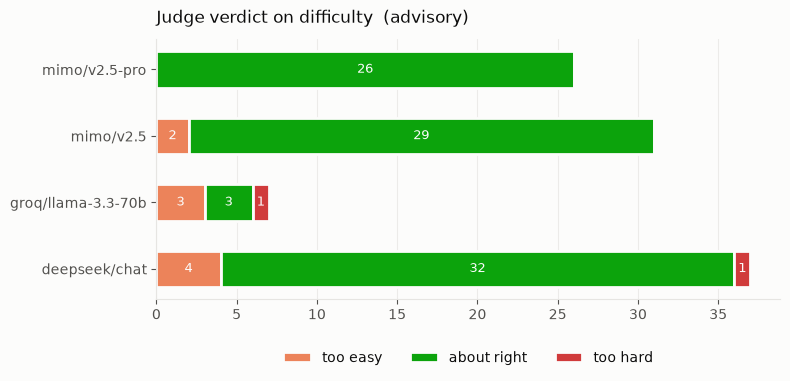

CAUTION: ['mimo/v2.5-pro'] judged its own output. Discount those rows; add a third key to fix.


,mean,min,max
model_id,,,
deepseek/chat,4.03,2.00,5.00
groq/llama-3.3-70b,2.86,2.00,3.00
mimo/v2.5,4.19,2.00,5.00
mimo/v2.5-pro,4.19,2.00,5.00


In [7]:
# A FAILED verdict (judge.error set, coaching_sense 0 fallback) is silence, not
# an opinion — counting it as "poor by the judge" fabricated blind-spot rows.
j = df[df.judge.notna() & df.ok].copy()
if len(j):
    failed = j.judge.map(lambda x: bool(x.get("error")))
    if failed.any():
        print(f"judge failed on {int(failed.sum())}/{len(j)} rows (excluded below) — "
              "a reasoning-model judge truncates; prefer a plain chat model as EVAL_JUDGE")
    j = j[~failed]
if len(j):
    j["difficulty"] = j.judge.map(lambda x: x.get("difficulty"))
    j["sense"] = j.judge.map(lambda x: x.get("coaching_sense"))
    j["self"] = j.judge.map(lambda x: x.get("self_judged", False))

    order = ["too_easy", "about_right", "too_hard"]
    counts = (j.groupby(["model_id", "difficulty"]).size().unstack(fill_value=0)
               .reindex(columns=order, fill_value=0).reindex(MODELS))
    fig, ax = plt.subplots(figsize=(8, 1.6 + .6*len(MODELS)))
    left = np.zeros(len(counts))
    for col, c in zip(order, [SERIOUS, GOOD, CRITICAL]):
        b = ax.barh(counts.index, counts[col], left=left, color=c, height=.55,
                    label=col.replace("_", " "), edgecolor="#fcfcfb", linewidth=2)  # 2px surface gap
        ax.bar_label(b, labels=[str(v) if v else "" for v in counts[col]],
                     label_type="center", color="#fcfcfb", fontsize=9)
        left += counts[col].values
    ax.set_title("Judge verdict on difficulty  (advisory)", color=INK, fontsize=12, pad=12, loc="left")
    legend_below(ax, 3); bare(ax, x=True)
    plt.tight_layout(); plt.show()

    if j["self"].any():
        sj = sorted(j[j["self"]].model_id.unique())
        print(f"CAUTION: {sj} judged its own output. Discount those rows; add a third key to fix.")
    display(j.groupby("model_id").sense.agg(["mean", "min", "max"]).style.format("{:.2f}"))
else:
    print("No judge verdicts (ran with --no-judge, or every judge call failed).")

## 4. Does periodization actually happen?

Each check maps to a written rule, cited in `plan_checks.ts`:

| Check | Rule | Source |
|---|---|---|
| `hard_spacing` | never back-to-back hard; ≤ 2-3 hard/week | `prompt.ts:58`, `:476` |
| `polarization` | ~80% of endurance time in Z1-Z2 | `prompt.ts:47`, `:475` |
| `tss_target` | weekly load near the target | `prompt.ts:477` |
| `ramp` | volume up ≤ ~10% week on week | `prompt.ts:52` |
| `taper` | a taper cuts volume 40-60% | `prompt.ts:50-51` |
| `set_landmarks` | experience-tiered sets/muscle | `prompt.ts:79-88` |

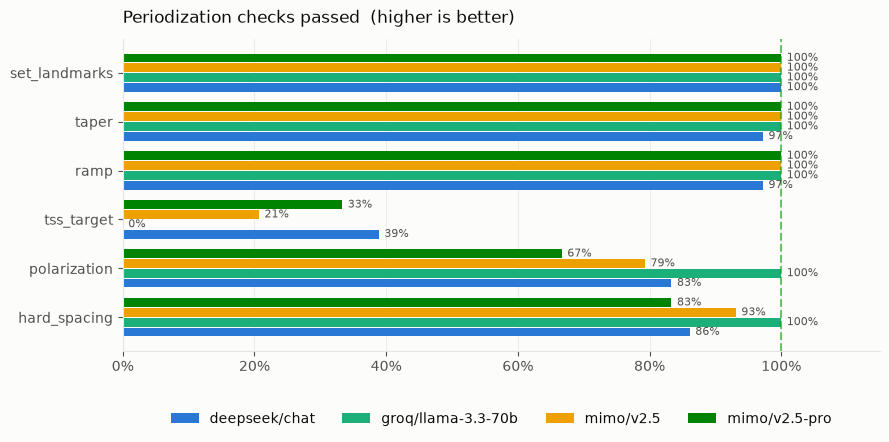

,hard_spacing,polarization,tss_target,ramp,taper,set_landmarks
model_id,,,,,,
deepseek/chat,86%,83%,39%,97%,97%,100%
groq/llama-3.3-70b,100%,100%,0%,100%,100%,100%
mimo/v2.5,93%,79%,21%,100%,100%,100%
mimo/v2.5-pro,83%,67%,33%,100%,100%,100%


In [8]:
if len(wk):
    ck = pd.DataFrame(list(wk.checks.values), index=wk.index)
    # Cast BEFORE grouping: `taper` is None on non-taper scenarios, which makes the
    # column object-dtype and numeric_only=True drops it silently — losing the single
    # most important periodization check from the chart. None -> NaN keeps it, and a
    # check that never asserted shows as "n/a" rather than vanishing.
    ck = ck.astype("float64").assign(model_id=wk.model_id.values)
    rates = ck.groupby("model_id").mean().reindex(MODELS)
    fig, ax = plt.subplots(figsize=(9, 1.6 + .5*len(rates.columns)))
    y = np.arange(len(rates.columns)); h = .8/len(MODELS)
    for i, m in enumerate(MODELS):
        if m not in rates.index: continue
        off = (i - (len(MODELS)-1)/2) * h
        vals = rates.loc[m].values
        bb = ax.barh(y + off, vals, height=h*.9, color=CMAP[m], label=m)
        ax.bar_label(bb, labels=[f"{v:.0%}" if pd.notna(v) else "n/a" for v in vals],
                     padding=4, fontsize=8, color=INK2)
    ax.set_yticks(y); ax.set_yticklabels(rates.columns)
    ax.set_xlim(0, 1.15); ax.xaxis.set_major_formatter(PercentFormatter(1))
    ax.axvline(1.0, color=GOOD, lw=1.5, ls="--", alpha=.6)
    ax.set_title("Periodization checks passed  (higher is better)", color=INK, fontsize=12, pad=12, loc="left")
    legend_below(ax, len(MODELS)); bare(ax, x=True)
    plt.tight_layout(); plt.show()
    display(rates.style.format("{:.0%}", na_rep="n/a").background_gradient(cmap="RdYlGn", vmin=0, vmax=1))

In [9]:
# The two rules most likely to be quietly ignored, isolated.
for name, label in [("week/taper-1wk", "TAPER: must cut volume 40-60%"),
                    ("week/periodized/deload-due", "DELOAD: must cut ~40% after 4 build weeks")]:
    sub = wk[wk.scenario == name] if len(wk) else pd.DataFrame()
    print(f"\n{label}")
    if not len(sub):
        print("  (not in this tier)"); continue
    for _, r in sub.iterrows():
        d = (r.check_detail or {})
        cut = (d.get("taper") or {}).get("cut_pct")
        prior, tot = r.week["target_tss"], r.week["total_tss"]
        got = f"cut {cut:.0%}" if cut is not None else f"{tot} TSS vs {prior} target"
        ok = r.checks.get("taper") if cut is not None else r.checks.get("tss_target")
        print(f"  [{r.model_id} #{r.repeat}] {got}  ->  {'PASS' if ok else 'FAIL'}")


TAPER: must cut volume 40-60%
  [mimo/v2.5 #<bound method Series.repeat of run_id                                                                                2026-07-18T20-52-36-234Z
scenario                                                                                        week/taper-1wk
kind                                                                                                      week
catches                    taper must cut volume 40-60% (prompt.ts:50-51), the single most testable phase rule
tier                                                                                                     smoke
meta                                                     {'phase': 'Taper', 'weeks_to_goal': 1, 'race': 'one'}
model_id                                                                                             mimo/v2.5
provider                                                                                            openrouter
model                               

## 5. Race, no race, and multiple races

**Finding, established in code rather than sampled:** the `races` table is read in exactly
one place — `_shared/coach_tools.ts:239`, the chat coach's `get_profile`. **No planner
reads it.** Every periodization decision derives from a single scalar,
`onboarding.goal_date`, and `set_goal_race` writes only that scalar.

So server-side:

- **multiple races ≡ one race.** B and C races are invisible to every planner. There is no
  A/B/C periodization; the prompts are byte-identical.
- **a past goal_date ≡ no race.** It silently becomes `"General / maintenance"`.

The runner asserts the first claim directly (`proveMultiRaceIsIdenticalToOne`) rather than
paying for LLM calls to infer it. Below is that assertion plus how phase actually lands.

In [10]:
claims = LATEST.with_suffix("").with_suffix("")  # strip .jsonl
claims = pathlib.Path(str(LATEST).replace(".jsonl", ".claims.json"))
if claims.exists():
    c = json.loads(claims.read_text())
    verdict = "PROVEN" if c["multi_race_identical_to_one"] else "NOT PROVEN — investigate"
    print(f"multi-race prompt == one-race prompt:  {verdict}\n")
    print(c["explanation"])
else:
    print("no .claims.json beside this run")

race = df[df.meta.map(lambda m: "race" in (m or {}))].copy()
if len(race):
    race["race"] = race.meta.map(lambda m: m["race"])
    race["phase"] = race.meta.map(lambda m: m.get("phase"))
    print("\nHow each race state actually reaches the planner:\n")
    display(race.groupby(["race", "phase"]).agg(scenarios=("scenario", "nunique"),
                                                valid=("ok", "mean"),
                                                violations=("violations", lambda s: np.mean([len(x) for x in s])))
                .style.format({"valid": "{:.0%}", "violations": "{:.1f}"}))

no .claims.json beside this run

How each race state actually reaches the planner:



## 6. Model comparison

The plug-and-play table. Add a model in `scripts/eval/models.ts`, export its key, re-run
— it appears here automatically.

**Variance across repeats matters as much as the mean.** A model that passes once and
fails twice on the same seeded prompt is not a model you can ship; the spread column is
the honest read.

In [11]:
summary = df.assign(nv=df.violations.map(len), nu=df.unsafe.map(len)).groupby("model_id").agg(
    runs=("ok", "size"),
    valid=("ok", "mean"),
    violations_per_run=("nv", "mean"),
    unsafe=("nu", "sum"),
    tokens_in=("prompt_tokens", "sum"),
    tokens_out=("completion_tokens", "sum"),
    cost=("cost_usd", "sum"),
    median_ms=("ms", "median"),
).reindex(MODELS)
summary["cost_per_run"] = summary.cost / summary.runs
display(summary.style.format({
    "valid": "{:.0%}", "violations_per_run": "{:.2f}", "cost": "${:.4f}",
    "cost_per_run": "${:.4f}", "median_ms": "{:.0f}",
}).background_gradient(subset=["violations_per_run"], cmap="Reds")
  .background_gradient(subset=["valid"], cmap="Greens"))

,runs,valid,violations_per_run,unsafe,tokens_in,tokens_out,cost,median_ms,cost_per_run
model_id,,,,,,,,,
deepseek/chat,72,100%,0.75,1,177060,124829,$0.1020,10846,$0.0014
groq/llama-3.3-70b,72,22%,0.11,2,37832,12711,$0.0324,75378,$0.0004
mimo/v2.5,72,74%,0.64,3,165613,167029,$0.0700,28083,$0.0010
mimo/v2.5-pro,72,47%,0.46,1,180104,239635,$0.2868,50207,$0.0040


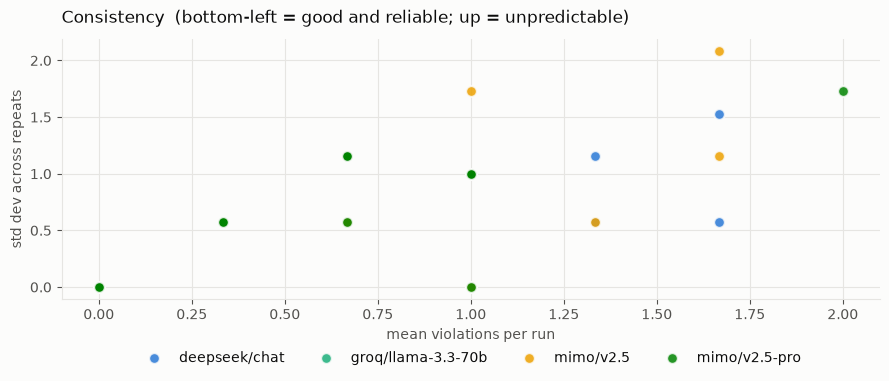

Least reproducible scenario/model pairs (same seed, different answers):


,model_id,scenario,mean,std
70,mimo/v2.5,week/taper-1wk,1.7,2.08
52,mimo/v2.5,run/int/wrecked,1.0,1.73
76,mimo/v2.5-pro,run/int/wrecked,2.0,1.73
19,deepseek/chat,week/periodized/build-week-3,1.7,1.53
62,mimo/v2.5,week/hard-spacing,1.7,1.15
1,deepseek/chat,run/int/fatigued-amber,1.3,1.15
9,deepseek/chat,strength/int/lower-back-injury,0.7,1.15
87,mimo/v2.5-pro,week/multi-race,0.7,1.15


In [12]:
# Variance: same scenario, same seed, repeated. Spread = unreliability.
if df.repeat.nunique() > 1:
    v = (df.assign(nv=df.violations.map(len)).groupby(["model_id", "scenario"]).nv
           .agg(["mean", "std"]).reset_index())
    fig, ax = plt.subplots(figsize=(9, 4))
    for m in MODELS:
        s = v[v.model_id == m]
        ax.scatter(s["mean"], s["std"].fillna(0), color=CMAP[m], s=60, alpha=.85,
                   edgecolor="#fcfcfb", linewidth=1.5, label=m)
    ax.set_xlabel("mean violations per run"); ax.set_ylabel("std dev across repeats")
    ax.set_title("Consistency  (bottom-left = good and reliable; up = unpredictable)",
                 color=INK, fontsize=12, pad=12, loc="left")
    legend_below(ax, len(MODELS)); plt.tight_layout(); plt.show()

    worst = v.dropna(subset=["std"]).sort_values("std", ascending=False).head(8)
    if len(worst) and worst["std"].max() > 0:
        print("Least reproducible scenario/model pairs (same seed, different answers):")
        display(worst.style.format({"mean": "{:.1f}", "std": "{:.2f}"}))
else:
    print("Single repeat: no variance to measure. Use --repeats 3 for that.")

## 7. Judge vs the checkers

The disagreement matrix. Each cell is a claim about which signal is wrong:

- **Judge says fine, checker says violation** → either the judge is too soft, or the rule
  is pedantic and worth revisiting. Check the examples before assuming the model is at fault.
- **Judge says bad, checker says clean** → the interesting quadrant. A gap in our
  deterministic coverage: something is wrong that no rule of ours can see. That is where
  the next checker comes from.

In [13]:
if len(j):
    j["det_clean"] = j.violations.map(len) == 0
    j["judge_ok"] = j.sense >= 4
    x = pd.crosstab(j.det_clean, j.judge_ok).rename(
        index={True: "checker: clean", False: "checker: violations"},
        columns={True: "judge: good (4-5)", False: "judge: poor (1-3)"})
    display(x)
    agree = (j.det_clean == j.judge_ok).mean()
    print(f"\nagreement: {agree:.0%}")

    gap = j[j.det_clean & ~j.judge_ok]
    print(f"\nBLIND SPOT — clean by our rules, poor by the judge: {len(gap)} rows")
    print("If this is non-trivial, our checkers are missing something real:\n")
    for _, r in gap.head(6).iterrows():
        print(f"  [{r.model_id}] {r.scenario}")
        print(f"      sense {r.sense}/5 | {r.judge.get('reasoning','')[:150]}")
        for b in (r.judge.get("rule_breaches") or [])[:3]: print(f"      - {b}")
else:
    print("No judge data.")

judge_ok,judge: poor (1-3),judge: good (4-5)
det_clean,,
checker: violations,19,54
checker: clean,4,24



agreement: 43%

BLIND SPOT — clean by our rules, poor by the judge: 4 rows
If this is non-trivial, our checkers are missing something real:

  [groq/llama-3.3-70b] strength/int/full-gym/fresh
      sense 3/5 | The session uses the correct lower-body focus and respects the progression targets, but it fails to prioritize the many under-trained muscle groups (s
      - hypertrophy rep range
      - exercise order
      - under-trained muscles
  [groq/llama-3.3-70b] run/int/fresh/build
      sense 2/5 | Stacking a 20-min threshold run with 3x4-min VO2max intervals delivers 32 minutes of Z3+ quality in one session—each block alone would be a proper Bui
      - key run types - combined threshold + VO2max in single session exceeds intermediate-appropriate quality volume
      - VO2max work:rest ratio not ~1:1 (3 min rest for 4 min reps)
  [deepseek/chat] week/periodized/deload-due
      sense 3/5 | The deload volume and intensity reduction are appropriate, but placing two hard run sessions (

## 8. Verdict: prompt, data, or model?

Read the evidence above against these three, in order. The order matters — the cheap fixes
come first, and "change the model" is the expensive last resort.

**It's the PROMPT if…**
- every model breaks the *same* rule at a similar rate. A rule the strongest model also
  breaks is a rule that isn't really in the prompt, or is contradicted elsewhere in it.
- violations cluster on `week_*` kinds (the rules that were prose-only until now — the
  model was being asked to follow something nothing verified).
- a `contradiction` scenario fires: `plan_checks.KNOWN_CONTRADICTIONS` lists places where
  the prompt and the checker disagree, so **no** model can satisfy both. That's a spec
  bug, and no amount of model swapping fixes it. (The original three — tiered weekly
  sets, the amber recovery cap, invisible swims — are fixed and enforced now; the tagged
  scenarios remain to measure how often models NEED the enforcement.)

**It's the DATA/CONTEXT if…**
- failures concentrate in scenarios where a fact reaches the *checker* but never the
  *prompt* (`strength/int/knee-injury` is built exactly this way — the injury is in the
  review context, and in the real app it arrives via `coach_knowledge`).
- the judge's blind-spot quadrant (section 7) is full: the output is legal but ungrounded.

**It's the MODEL if…**
- one model is materially worse on the *same* prompts, especially on schema validity or
  variance across repeats.
- the gap survives a prompt fix.

Then re-run and compare: `scripts/dev.sh eval:run` writes a new timestamped JSONL, so
two runs are directly diffable.

In [14]:
# Everything each scenario was built to catch, and whether it caught it.
out = (df.assign(nv=df.violations.map(len), nu=df.unsafe.map(len))
         .groupby(["kind", "scenario", "catches"])
         .agg(valid=("ok", "mean"), violations=("nv", "mean"), unsafe=("nu", "sum"))
         .sort_values(["kind", "violations"], ascending=[True, False]))
display(out.style.format({"valid": "{:.0%}", "violations": "{:.1f}"})
          .background_gradient(subset=["violations"], cmap="Reds"))

print("\nKnown spec contradictions — no model can satisfy both sides of these:")
for c in ["weekly-sets: prompt is experience-tiered (8-12/12-18/16-22+), the checker is a flat 22",
          "recovery-cap: context.ts promises amber -> RPE 6, but nothing checks it (ceiling is readiness<35 -> RPE 5)",
          "swim: isHardSession/computeTss are run/ride only, so a hard swim is invisible to spacing"]:
    print(f"  - {c}")


Known spec contradictions — no model can satisfy both sides of these:
  - weekly-sets: prompt is experience-tiered (8-12/12-18/16-22+), the checker is a flat 22
  - recovery-cap: context.ts promises amber -> RPE 6, but nothing checks it (ceiling is readiness<35 -> RPE 5)
  - swim: isHardSession/computeTss are run/ride only, so a hard swim is invisible to spacing
